# Modelos de regresión lineal

Los modelos de regresión lineal son aquellos que intentan encontrar una ecuación del tipo:
$$ y = f(X) $$
donde **X** son un conjunto de variables, o características, predictoras, y $y$ es la variable por predecir.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Se va a trabajar con un dataset sintético con solo 2 variables, una de entrada, y otra de salida.

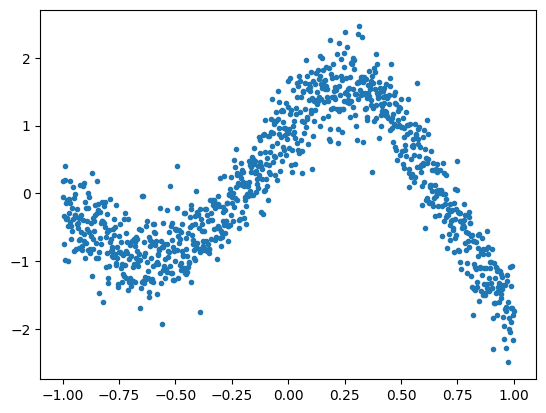

In [ ]:
X = np.linspace(-1, 1, 1000)# Generamos 1000 puntos entre -1 y 1
ruido = np.random.normal(0, 0.333, 1000)# Generamos ruido normal 
y = np.sin(4*X) + np.cos(3*X) + ruido# Generamos los valores de y
plt.plot(X,y, '.');# Graficamos los puntos

El modelo más simple que se puede construir es una línea recta de la forma:
$$ y = w_0 + w_{1}*x$$

Donde $w_0$ es el intercepto de la línea y $w_1$ es la pendiente de la línea.

Con un modelo de regresión lineal simple se pueden encontrar los mejores valores de estos parámetros.

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
X = X.reshape(-1,1)
model.fit(X,y)
model.score(X,y)# El modelo no se ajusta bien a los datos ya que este dio muy cerca a 0.(el modelo no es bueno)

0.044323842535730185

In [5]:
print(f'El intercepto del modelo es {model.intercept_:.3f}')
print(f'La pendiente del modelo es {model.coef_[0]:.3f}')

El intercepto del modelo es 0.039
La pendiente del modelo es 0.370


Si se compara lo que predice el modelo contra los datos reales, evidentemente el modelo es malísimo.

Aqui esta la grafica del modelo, la linea roja es el modelo(la linea recta que me da el menor error), en este caso el modelo es muy simple, no se ajusta muy bien a los datos, desde aqui empezamos a mejorar el modelo.

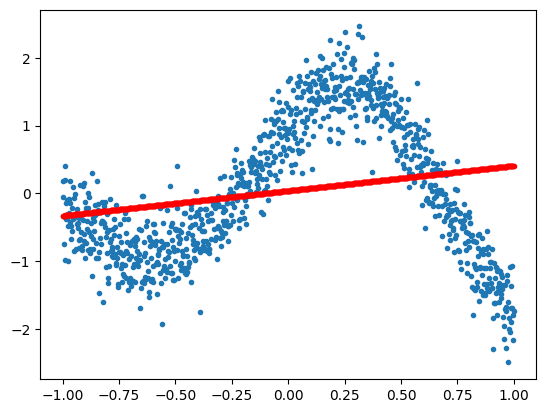

In [6]:
plt.plot(X,y, '.')
plt.plot(X, model.predict(X), 'r.');

Para poder **cuantificar** que tan bueno es un modelo es necesario usar una **métrica de evaluación**. El método `score` mide el modelo usando una métrica, que en este caso es el [coeficiente de determinación](https://es.wikipedia.org/wiki/Coeficiente_de_determinaci%C3%B3n) o $R^2$.

Mientrar el $R^2$ este mas cerca a uno mejor el modelo, esta es una metrica adecuada para modelos lineales no para otras.

In [6]:
print(f'R^2 del modelo: {model.score(X,y):.3f}')

R^2 del modelo: 0.043


# Métricas de evaluación

Este resultado nos corrobora que este modelo es malísimo, porque mientras más cerca a 0 peor, y mientras más cerca a 1, mejor.

Sin embargo, es posible, y deseable, usar otras métricas. Scikit Learn tiene un buen conjunto de métricas implementadas (que puede consultar [aquí](https://scikit-learn.org/stable/modules/model_evaluation.html)).
Métricas de regresión muy utilizadas son el **MSE** ([Mean squared error](https://es.wikipedia.org/wiki/Error_cuadr%C3%A1tico_medio)), **RMSE** (Root mean squared error), el **MAE** ([Mean absolute error](https://es.wikipedia.org/wiki/Error_absoluto_medio)), y el [Median absolute error](https://scikit-learn.org/stable/modules/model_evaluation.html#median-absolute-error).

Es importante notar que las **métricas de evaluación** son funciones que tienen el propósito de evaluar el modelo, mientras que las **funciones de error** son las funciones que intenta optimizar el algoritmo de optimización que encuentra los parámetros del modelo. De esta manera, pueden ser funciones matemáticas diferentes (o las mismas también).

* Una funcion de costos es la que utilizo para optimizar el modelo

* Una metrica es uan funcion que yo utilizo para evaluar el proyecto 

1. IDEA CLAVE (lo más importante)

Hay dos cosas diferentes:

 Función de costo (loss)

-  Se usa para ENTRENAR el modelo, es decir tomar la funcion , hacer que se acerque lo mas posible a los puntos reales

- El algoritmo intenta minimizarla

 Métrica

- Se usa para EVALUAR qué tan bueno quedó el modelo, que tan cerca estuvo el modelo al momento de predecir los datos, que tan cerca estan los datos predecidos con los reales.

-  Solo mide, no entrena

¿Cómo se optimiza?

El modelo tiene una función, por ejemplo:

y = ax² + bx + c

Esos valores (a, b, c) son los que se ajustan, para que los puntos predichos de la funcion queden lo mas cerca posible a los puntos reales

**Funcion MSE**

Como MÉTRICA (evaluación)

- Se usa para evaluar qué tan bueno quedó el modelo

- Mide qué tan cerca están las predicciones de los valores reales

El MSE mas importante tambien es funcion de costo (optimizacion)

Calcula el error entre:

valor real: Y real

predicción: Y esperado

Eleva al cuadrado (castiga errores grandes)

El modelo intenta que esto sea lo más pequeño posible

El MSE para evaluar u optimizar? Ambas cosas

1. Se usa como función de costo (muy común)

2. También como métrica de evaluación

Depende del contexto:

Durante entrenamiento → costo

Después del entrenamiento → métrica







In [7]:
from sklearn.metrics import root_mean_squared_error, median_absolute_error

# Aqui les entrego el valor real de y vs el valor que predice el modelo, para calcular el error de cada una de las métricas.

print(f'RMSE del modelo: {root_mean_squared_error(y, model.predict(X)):.3f}')# RMSE es la raíz cuadrada del error cuadrático medio.
print(f'MedAE del modelo: {median_absolute_error(y, model.predict(X)):.3f}')# MedAE es la mediana del error absoluto.

RMSE del modelo: 0.992
MedAE del modelo: 0.724


# Extracción de características

Se podría intentar obtener un mejor modelo **añadiendo nuevas características** al modelo, en este caso, elevando la variable predictora a alguna potencia. Esto se llama un **modelo de regresión polinómica**.

Vamos a empezar con un modelo polinómico de grado 2, de la forma:
$$ y = w_0 + w_{1}*x + w_{2}*x^2$$

Aunque esto se podría hacer a mano en este caso simple, se va a usar el método `PolynomialFeatures` de Scikit Learn.


In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_p = poly.fit_transform(X)
X_p

#Este por defecto te crea una columna de X^0, en este caso no la muestra por que la variabel include_bias esta falsa 

#Cada columna de la matriz es una potencia de la variable X, desde la potencia 1 hasta la potencia 2. La primera columna es X^1 y
# la segunda columna es X^2.

array([[-1.        ,  1.        ],
       [-0.997998  ,  0.996     ],
       [-0.995996  ,  0.99200802],
       ...,
       [ 0.995996  ,  0.99200802],
       [ 0.997998  ,  0.996     ],
       [ 1.        ,  1.        ]], shape=(1000, 2))

In [15]:
model.fit(X_p,y)
print(f'R^2 del modelo: {model.score(X_p,y):.3f}')
print(f'RMSE del modelo: {root_mean_squared_error(y, model.predict(X_p)):.3f}')
print(f'MedAE del modelo: {median_absolute_error(y, model.predict(X_p)):.3f}')

#Al compara este modelo con el modelo lineal, se puede observar que el modelo polinómico tiene un R^2 mucho mayor, un RMSE mucho menor y
#un MedAE mucho menor, lo que indica que el modelo polinómico se ajusta mucho mejor a los datos que el modelo lineal.

R^2 del modelo: 0.470
RMSE del modelo: 0.739
MedAE del modelo: 0.609


Evidentemente el modelo mejora, aunque todavía es malo.

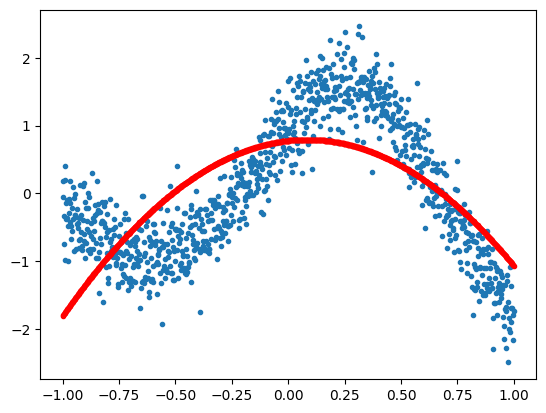

In [16]:
plt.plot(X,y, '.')
plt.plot(X, model.predict(X_p), 'r.');

Este modelo ya tendría 3 parámetros: el intercepto, la pendiente del término lineal, y la pendiente del término cuadrático.

In [11]:
print(f'El intercepto del modelo es {model.intercept_:.3f}')
print(f'El coeficiente del término lineal del modelo es {model.coef_[0]:.3f}')
print(f'El coeficiente del término cuadrático del modelo es {model.coef_[1]:.3f}')

El intercepto del modelo es 0.790
El coeficiente del término lineal del modelo es 0.356
El coeficiente del término cuadrático del modelo es -2.195


Ahora, se va a probar con un modelo polinómico de grado 3.

---

Now, it is going to be tested with a polynomial model of grade 3.

In [12]:
poly = PolynomialFeatures(degree=3, include_bias=False)
X_p = poly.fit_transform(X)
X_p

array([[-1.        ,  1.        , -1.        ],
       [-0.997998  ,  0.996     , -0.99400601],
       [-0.995996  ,  0.99200802, -0.98803602],
       ...,
       [ 0.995996  ,  0.99200802,  0.98803602],
       [ 0.997998  ,  0.996     ,  0.99400601],
       [ 1.        ,  1.        ,  1.        ]])

In [13]:
model.fit(X_p,y)
print(f'R^2 del modelo: {model.score(X_p,y):.3f}')
print(f'RMSE del modelo: {root_mean_squared_error(y, model.predict(X_p)):.3f}')
print(f'MedAE del modelo: {median_absolute_error(y, model.predict(X_p)):.3f}')

R^2 del modelo: 0.832
RMSE del modelo: 0.408
MedAE del modelo: 0.273


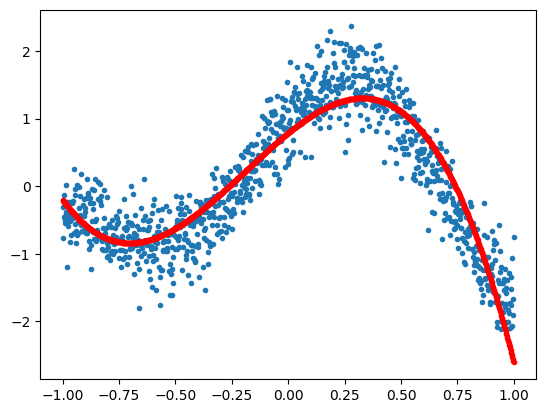

In [14]:
plt.plot(X,y, '.')
plt.plot(X, model.predict(X_p), 'r.');

In [15]:
print(f'El intercepto del modelo es {model.intercept_:.3f}')
print(f'El coeficiente del término lineal del modelo es {model.coef_[0]:.3f}')
print(f'El coeficiente del término cuadrático del modelo es {model.coef_[1]:.3f}')
print(f'El coeficiente del término cúbico del modelo es {model.coef_[2]:.3f}')

El intercepto del modelo es 0.790
El coeficiente del término lineal del modelo es 2.705
El coeficiente del término cuadrático del modelo es -2.195
El coeficiente del término cúbico del modelo es -3.907


Pareciera que mientras más alto sea el grado del modelo, mejor predice. Se va a verificar con grados más altos de polinomios:

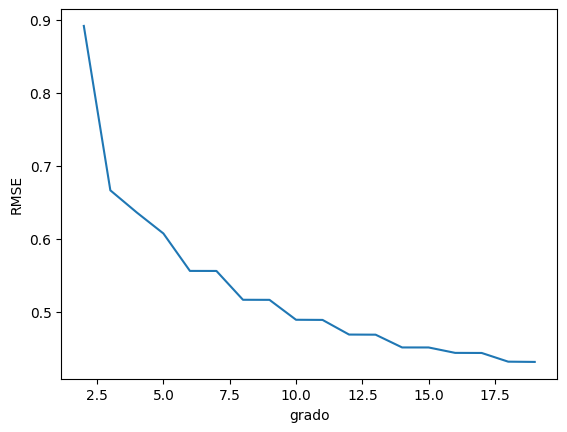

In [17]:
degrees = range(2,20)
scores_rmse = []
for degree in degrees:
  poly = PolynomialFeatures(degree=degree, include_bias=False)
  X_p = poly.fit_transform(X)
  model.fit(X_p,y)
  scores_rmse.append(root_mean_squared_error(y, model.predict(X_p)))

fig = plt.figure()
plt.plot(degrees, scores_rmse, '-')
plt.xlabel('grado')
plt.ylabel('RMSE');

Se observa que después de cierto grado (5 o 6), el modelo mejora muy poco, así que aumentar la complejidad del modelo no garantiza que funcione mejor.

In [18]:
scores = pd.DataFrame({'grado': degrees, 'RMSE': scores_rmse})
scores.set_index('grado', inplace=True)
scores.sort_values(by='RMSE', ascending=True).head(10)

,RMSE
grado,
19,0.430929
18,0.431276
17,0.443207
16,0.443324
15,0.450748
14,0.450771
13,0.468278
12,0.468440
11,0.488515


En este caso el error se acerca asintóticamente a la desviación estándar del ruido, pero nunca va a ser menor a este.

R^2 del modelo: 0.856
RMSE del modelo: 0.377


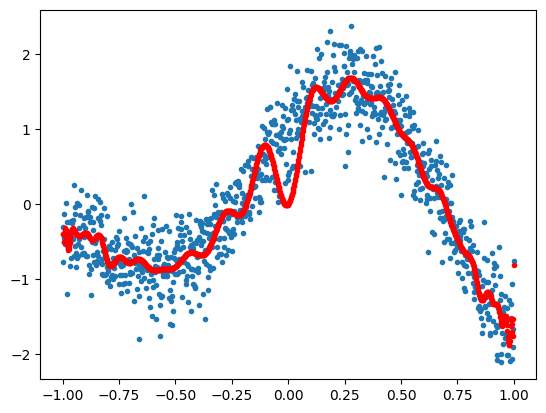

In [19]:
poly = PolynomialFeatures(degree=100, include_bias=False)
X_p = poly.fit_transform(X)
model.fit(X_p,y)
print(f'R^2 del modelo: {model.score(X_p,y):.3f}')
print(f'RMSE del modelo: {root_mean_squared_error(y, model.predict(X_p)):.3f}')
plt.plot(X,y, '.')
plt.plot(X, model.predict(X_p), 'r.');

Por otra parte, los coeficientes se hacen más grandes a medida que aumenta  el grado del polinomio:

In [20]:
model.coef_

array([ 3.89857532e+00,  2.41282927e+02, -1.06523309e+02, -1.78815989e+04,
        7.78543014e+03,  5.97209356e+05, -2.37591030e+05, -1.11545114e+07,
        3.84205547e+06,  1.29519307e+08, -3.75797237e+07, -9.92381772e+08,
        2.37519240e+08,  5.17464587e+09, -9.98543629e+08, -1.84912949e+10,
        2.78234917e+09,  4.42868745e+10, -4.87372135e+09, -6.55801040e+10,
        4.39319042e+09,  4.39613632e+10,  1.98822442e+08,  1.99596249e+10,
       -3.65151301e+09, -4.30892304e+10,  3.24425688e+08, -1.31092311e+10,
        3.10806426e+09,  3.42256423e+10,  7.20942863e+08,  2.31689902e+10,
       -2.34427940e+09, -1.77578628e+10, -2.11522823e+09, -3.17555701e+10,
        4.88684202e+08, -8.51009476e+09,  2.31755817e+09,  2.09978812e+10,
        1.75442856e+09,  2.75100575e+10, -3.26698673e+08,  8.99937818e+09,
       -1.97662022e+09, -1.53770874e+10, -1.96359326e+09, -2.57898623e+10,
       -5.16512074e+08, -1.63981017e+10,  1.21004456e+09,  3.82949704e+09,
        2.04509003e+09,  

In [21]:
model.intercept_

0.0